Loaded rows: 412
Step range: 1 -> 16650


,kind,step,optimizer_step,micro_step,lr,lambda_sparsity,loss,reconstruction_loss,sparsity_loss,l0_mean,nmse_mean,l0_by_layer,nmse_by_layer,eval_nmse_mean,eval_l0_mean,eval_nmse_by_layer,eval_l0_by_layer
407,train,16500,16500,33000.0,0.000098,0.00005,0.254715,0.254714,0.012268,80.703674,0.254714,"[17.41650390625, 3.31396484375, 4.076171875, 5...","[0.1686006337404251, 0.35233086347579956, 0.00...",NaN,NaN,NaN,NaN
408,eval,16500,16500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.282732,84.105542,"[0.1946810632944107, 0.3909932076931, 0.002810...","[18.837793350219727, 3.510974168777466, 3.9454..."
409,train,16550,16550,33100.0,0.000098,0.00005,0.302509,0.302508,0.012512,82.017131,0.302508,"[19.80810546875, 3.54296875, 3.77392578125, 5....","[0.2100212574005127, 0.40145912766456604, 0.00...",NaN,NaN,NaN,NaN
410,train,16600,16600,33200.0,0.000097,0.00005,0.289427,0.289426,0.012939,84.592244,0.289426,"[19.486328125, 3.2294921875, 3.9794921875, 5.3...","[0.19950729608535767, 0.3896903693675995, 0.00...",NaN,NaN,NaN,NaN
411,train,16650,16650,33300.0,0.000097,0.00005,0.324671,0.324670,0.012756,83.046041,0.324670,"[18.30859375, 3.37451171875, 3.95703125, 5.167...","[0.2117338478565216, 0.41742265224456787, 0.00...",NaN,NaN,NaN,NaN


Rolling smoothing window: 20


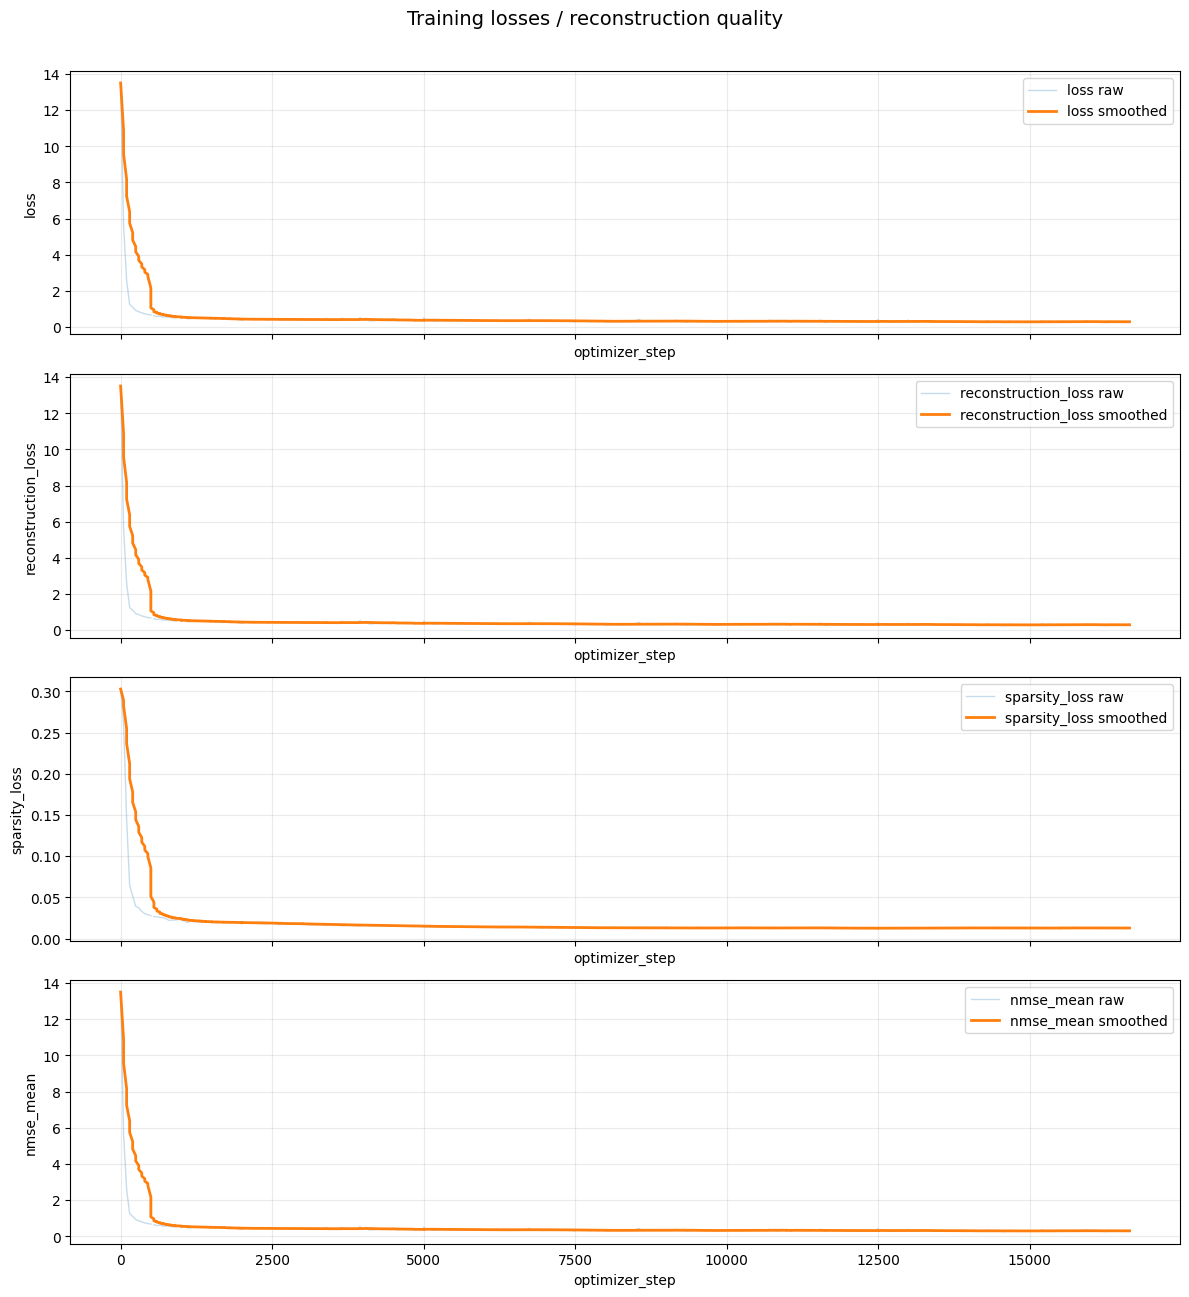

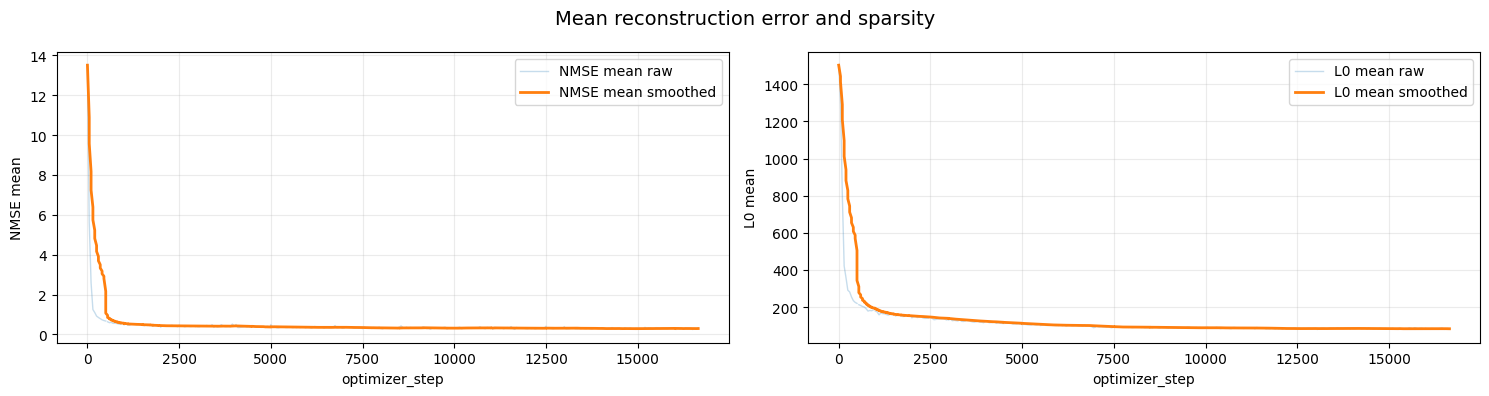

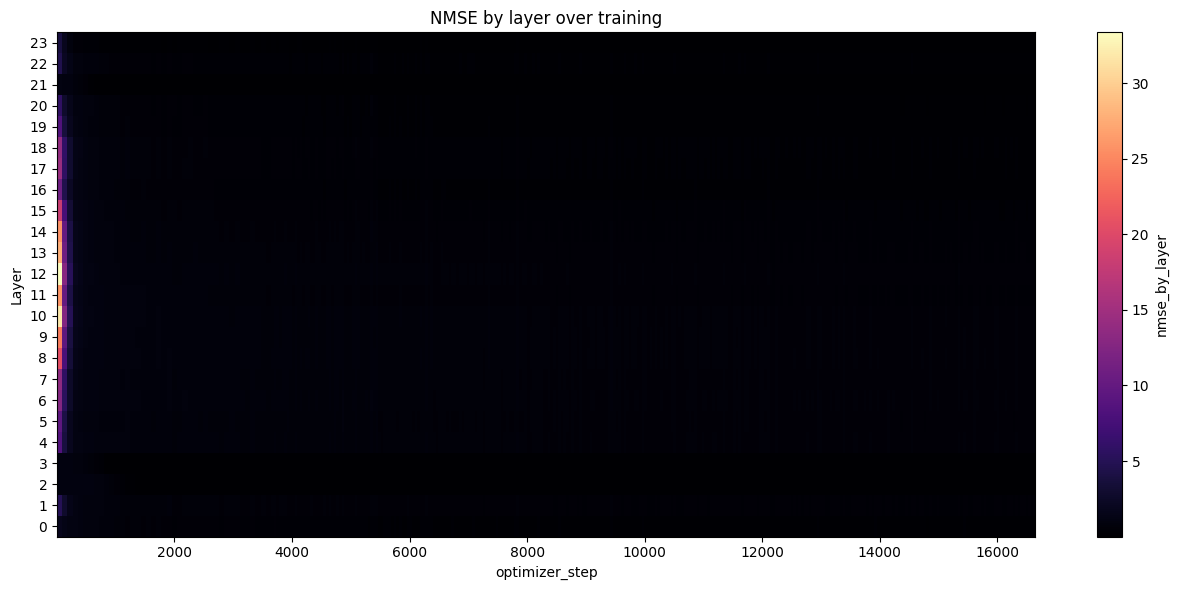

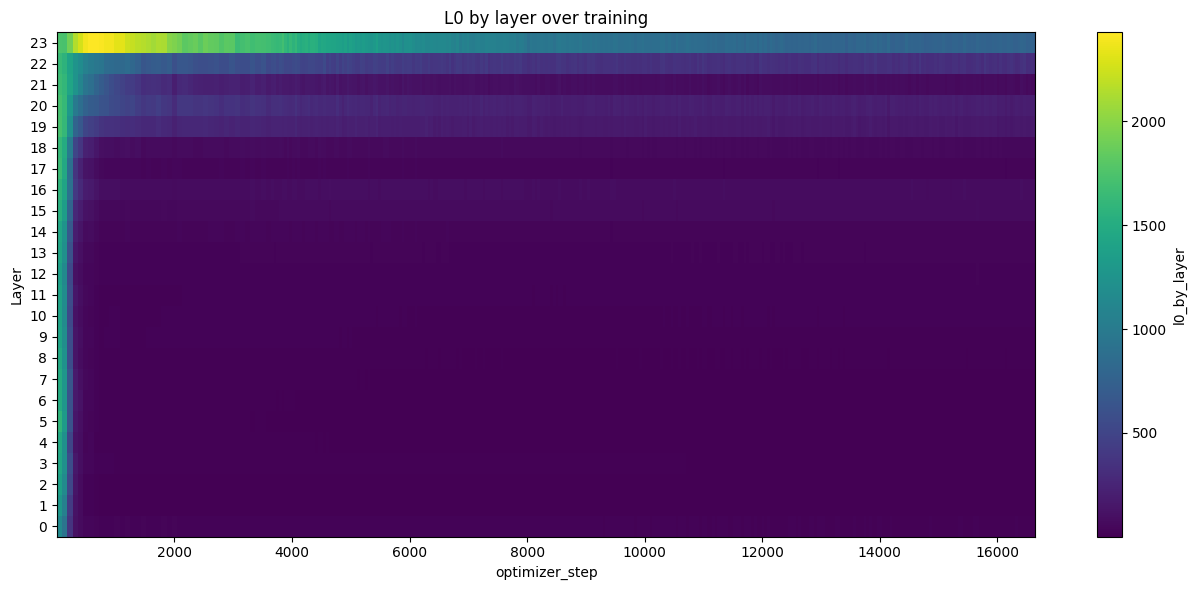

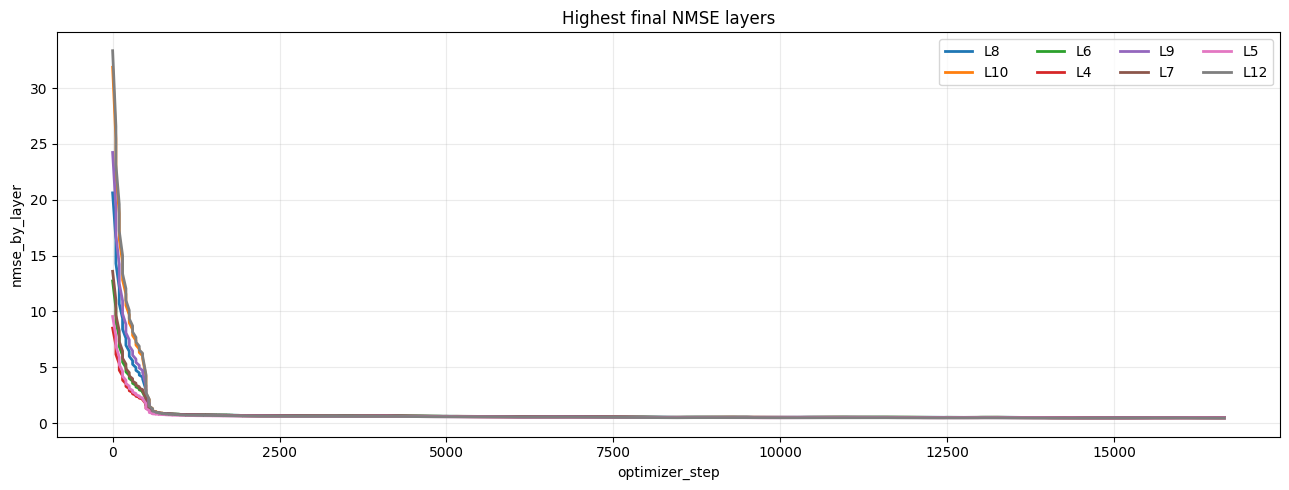

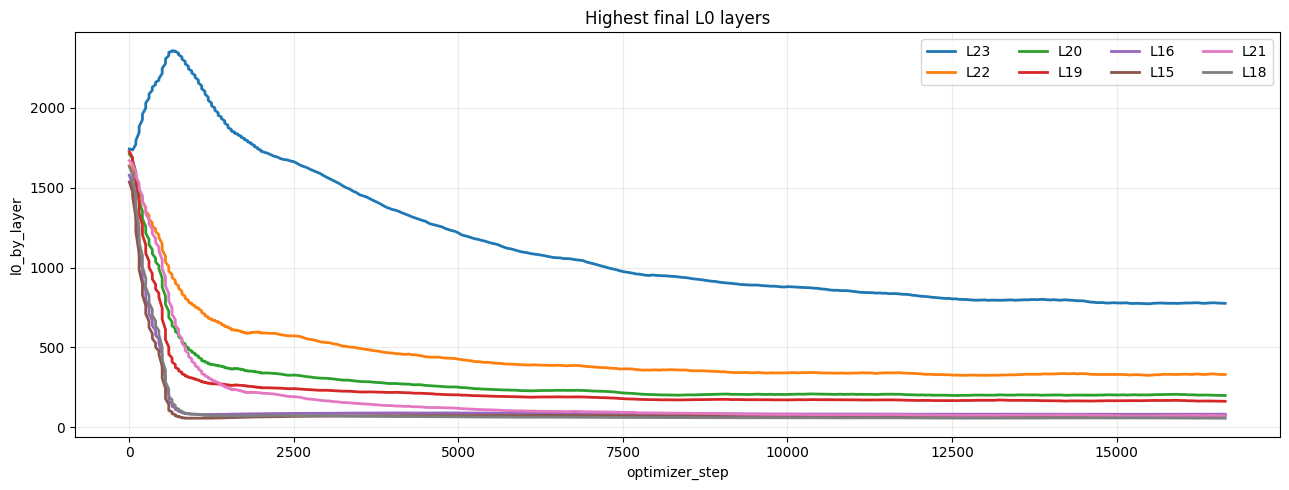

,metric,first,last,best_step,best_value
0,loss,13.504840,0.324671,16500,0.254715
1,reconstruction_loss,13.504840,0.324670,16500,0.254714
2,sparsity_loss,0.302734,0.012756,12100,0.012085
3,nmse_mean,13.504839,0.324670,16500,0.254714
4,l0_mean,1503.376363,83.046041,1,1503.376363


Saved plots to: /home/jupyter/project/LLM_interp/outputs/4096f_v1/training_plots


In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

METRICS_PATH = Path("/home/jupyter/project/LLM_interp/outputs/4096f_v1/metrics.jsonl")
PLOTS_DIR = METRICS_PATH.parent / "training_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

rows = []
with METRICS_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

step_col = "optimizer_step" if "optimizer_step" in df.columns else "step"
df = df.sort_values(step_col).reset_index(drop=True)

print(f"Loaded rows: {len(df)}")
print(f"Step range: {df[step_col].min()} -> {df[step_col].max()}")
display(df.tail(5))

window = max(5, min(100, len(df) // 20))
print(f"Rolling smoothing window: {window}")


def numeric_series(name):
    if name not in df.columns:
        return None
    s = pd.to_numeric(df[name], errors="coerce")
    if s.notna().sum() == 0:
        return None
    return s


def plot_metric(ax, name, label=None, logy=False):
    s = numeric_series(name)
    if s is None:
        return False

    x = df[step_col]
    label = label or name
    ax.plot(x, s, alpha=0.25, linewidth=1, label=f"{label} raw")
    ax.plot(x, s.rolling(window, min_periods=1).mean(), linewidth=2, label=f"{label} smoothed")
    ax.set_xlabel(step_col)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
    if logy:
        ax.set_yscale("log")
    ax.legend()
    return True


# 1. Main losses
loss_cols = [
    "loss",
    "reconstruction_loss",
    "sparsity_loss",
    "nmse_mean",
]

available_loss_cols = [c for c in loss_cols if numeric_series(c) is not None]

fig, axes = plt.subplots(len(available_loss_cols), 1, figsize=(12, 3.2 * len(available_loss_cols)), sharex=True)
if len(available_loss_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, available_loss_cols):
    plot_metric(ax, col, logy=False)

fig.suptitle("Training losses / reconstruction quality", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "01_losses.png", dpi=160, bbox_inches="tight")
plt.show()


# 2. NMSE and L0 together
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

plot_metric(axes[0], "nmse_mean", "NMSE mean", logy=False)
plot_metric(axes[1], "l0_mean", "L0 mean", logy=False)

fig.suptitle("Mean reconstruction error and sparsity", fontsize=14)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "02_nmse_l0.png", dpi=160, bbox_inches="tight")
plt.show()


# 3. Layerwise helpers
def layer_matrix(column):
    if column not in df.columns:
        return None

    values = []
    steps = []

    for _, row in df.iterrows():
        item = row.get(column)
        if isinstance(item, list) and len(item) > 0:
            values.append([float(x) for x in item])
            steps.append(row[step_col])

    if not values:
        return None

    return np.array(values, dtype=float), np.array(steps)


def plot_layer_heatmap(column, title, filename, cmap="viridis"):
    data = layer_matrix(column)
    if data is None:
        print(f"Skip {column}: no layerwise data")
        return

    mat, steps = data

    fig, ax = plt.subplots(figsize=(13, 6))
    im = ax.imshow(
        mat.T,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
        cmap=cmap,
        extent=[steps.min(), steps.max(), -0.5, mat.shape[1] - 0.5],
    )
    ax.set_title(title)
    ax.set_xlabel(step_col)
    ax.set_ylabel("Layer")
    ax.set_yticks(range(mat.shape[1]))
    fig.colorbar(im, ax=ax, label=column)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


plot_layer_heatmap("nmse_by_layer", "NMSE by layer over training", "03_nmse_by_layer_heatmap.png", cmap="magma")
plot_layer_heatmap("l0_by_layer", "L0 by layer over training", "04_l0_by_layer_heatmap.png", cmap="viridis")


# 4. Worst / most important layers as lines
def plot_top_layers(column, title, filename, top_k=8):
    data = layer_matrix(column)
    if data is None:
        return

    mat, steps = data
    final_values = mat[-1]
    top_layers = np.argsort(np.abs(final_values))[::-1][:top_k]

    fig, ax = plt.subplots(figsize=(13, 5))

    for layer in top_layers:
        y = pd.Series(mat[:, layer]).rolling(window, min_periods=1).mean()
        ax.plot(steps, y, linewidth=2, label=f"L{layer}")

    ax.set_title(title)
    ax.set_xlabel(step_col)
    ax.set_ylabel(column)
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=4)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


plot_top_layers("nmse_by_layer", "Highest final NMSE layers", "05_top_nmse_layers.png")
plot_top_layers("l0_by_layer", "Highest final L0 layers", "06_top_l0_layers.png")


# 5. Summary table
summary_cols = [
    "loss",
    "reconstruction_loss",
    "sparsity_loss",
    "nmse_mean",
    "l0_mean",
]

summary = []
for col in summary_cols:
    s = numeric_series(col)
    if s is None:
        continue

    best_idx = s.idxmin() if col != "l0_mean" else s.idxmax()
    summary.append({
        "metric": col,
        "first": float(s.iloc[0]),
        "last": float(s.iloc[-1]),
        "best_step": int(df.loc[best_idx, step_col]),
        "best_value": float(s.loc[best_idx]),
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

summary_df.to_csv(PLOTS_DIR / "training_summary.csv", index=False)

print(f"Saved plots to: {PLOTS_DIR}")